# 02 - Correlation Matrices Dataset (PyTorch)
In this notebook we build a PyTorch dataset of correlation matrices computed on rolling windows of log-returns.

Starting from the log-returns CSV saved under `data/processed/log_return_data`, we compute rolling-window correlation matrices.
- Correlation is computed on log-returns.
- The first day is removed because a return cannot be computed for the first observation.

Log-return formula:
$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$

To compute how many samples (i.e., windows/correlation matrices) you will obtain from your dataset, the formula is straightforward.

Let:
- $N$: total number of rows (days) in the log-returns dataset.
- $W$: window size (`WINDOW_LENGTH`).
- $S$: step between consecutive windows (`STRIDE`).

The formula for the number of windows $N_{windows}$ is:

$$
N_{windows} = \left\lfloor \frac{N - W}{S} \right\rfloor + 1
$$

In [1]:
from pathlib import Path
from typing import List, Tuple
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
import seaborn as sns

torch.set_printoptions(linewidth=200, precision=4, sci_mode=False)

In [2]:
# Editable parameters
FILE_NAME = 'data_00_20'
DATA_PATH = Path(f'../data/processed/{FILE_NAME}/log_return_data/log_returns_{FILE_NAME}.csv')
WINDOW_LENGTH = 252
STRIDE = 5
DTYPE = torch.float32

df = pd.read_csv(DATA_PATH)

print(f'Input log-returns matrix shape (days, assets+timestamp): {df.shape}')

# Numeric columns are the asset log-returns (timestamp is non-numeric)
log_returns_df = df.select_dtypes(include=[np.number]).copy()
print(f'Log-returns matrix shape used for correlation (days, assets): {log_returns_df.shape}')
df.head()

Input log-returns matrix shape (days, assets+timestamp): (5333, 101)
Log-returns matrix shape used for correlation (days, assets): (5333, 100)


,timestamp,ABC,ADP,AES,AIV,AJG,AKAM,ALL,AMZN,BDX,...,TRV,TYL,VAR,VNO,WAB,WBA,WM,WRB,XRAY,ZBRA
0,1999-11-02,-0.009541,-0.010458,0.017581,0.008097,0.003696,0.100875,-0.013334,-0.039690,0.019509,...,0.032963,0.028988,0.039434,0.027129,-0.012973,0.009974,-0.010185,0.029606,0.035318,-0.032208
1,1999-11-03,-0.032986,-0.009082,-0.025416,0.000000,0.019231,-0.009904,0.013334,-0.009527,0.023674,...,-0.021333,-0.028988,0.021979,-0.005795,-0.010391,0.007514,-0.009746,0.008118,-0.024418,-0.017659
2,1999-11-04,-0.009188,-0.009380,-0.003402,0.000000,0.010610,-0.096726,0.015220,-0.042685,0.083578,...,0.032588,-0.014696,0.018950,-0.003985,-0.067659,-0.007514,-0.020891,-0.005547,0.003031,-0.020337
3,1999-11-05,-0.029667,0.022449,0.021121,0.004931,0.044960,0.005754,0.010586,0.029377,-0.028518,...,0.086860,0.029410,-0.029879,0.015240,-0.014815,0.019655,0.003328,-0.024254,0.026452,-0.001092
4,1999-11-08,0.005531,0.018262,-0.004400,-0.003371,0.008969,0.073534,0.020841,0.183245,0.035091,...,-0.006957,-0.014715,-0.011050,-0.009421,0.025930,0.023847,0.017564,0.000000,-0.010582,0.046586


In [3]:
def sanitize_correlation_matrix(corr_matrix):
    """
    Sanitize a single correlation matrix (numpy array).
    
    Ensures values are in [-1, 1], makes matrix symmetric, and sets diagonal to 1.
    
    Args:
        corr_matrix: Correlation matrix as numpy array
    
    Returns:
        Sanitized correlation matrix
    """
    corr_matrix = np.clip(corr_matrix, -1.0, 1.0)
    corr_matrix = (corr_matrix + corr_matrix.T) / 2.0
    np.fill_diagonal(corr_matrix, 1.0)
    return corr_matrix

In [4]:
def build_correlation_windows(
    frame: pd.DataFrame,
    window_length: int,
    stride: int = 1,
    dtype: torch.dtype = torch.float32
) -> Tuple[torch.Tensor, List[Tuple[int, int]]]:
    
    # Select only numeric columns (exclude timestamp and other non-numeric columns)
    frame_numeric = frame.select_dtypes(include=[np.number]).copy()
    
    # The input frame already contains log-returns
    n_rows = len(frame_numeric)
    if n_rows < window_length:
        raise ValueError(
            f"Log-returns dataset too short ({n_rows} rows) for a window_length of {window_length}"
        )

    corr_mats = []
    windows = []

    # Iterate through time windows on log-returns
    for start in range(0, n_rows - window_length + 1, stride):
        end = start + window_length
        
        # .corr() defaults to Pearson correlation between columns
        window_corr = frame_numeric.iloc[start:end].corr().values
        
        # Sanitize the correlation matrix (clip values, ensure symmetry, set diagonal to 1)
        window_corr = sanitize_correlation_matrix(window_corr)
        
        # Convert to PyTorch Tensor
        corr_mats.append(torch.tensor(window_corr, dtype=dtype))
        windows.append((start, end))

    # Return the full stack (stack converts the list into a single 3D tensor)
    return torch.stack(corr_mats), windows

In [5]:
class RollingCorrelationDataset(Dataset):
    def __init__(
        self,
        frame: pd.DataFrame,
        window_length: int,
        stride: int = 1,
        dtype: torch.dtype = torch.float32,
    ) -> None:
        self.tensor, self.window_ranges = build_correlation_windows(
            frame=frame,
            window_length=window_length,
            stride=stride,
            dtype=dtype,
        )

    def __len__(self) -> int:
        return self.tensor.size(0)

    def __getitem__(self, idx: int):
        corr = self.tensor[idx]
        start, end = self.window_ranges[idx]
        return {
            'corr': corr,
            'window_start': start,
            'window_end': end,
        }

In [6]:
dataset = RollingCorrelationDataset(
    frame=df,
    window_length=WINDOW_LENGTH,
    stride=STRIDE,
    dtype=DTYPE,
    )

print(f'Number of windows: {len(dataset)}')
print(f'Single element shape: {dataset[0]["corr"].shape}')
print(f'Full tensor shape: {dataset.tensor.shape}')

sample = dataset[0]
sample

Number of windows: 1017
Single element shape: torch.Size([100, 100])
Full tensor shape: torch.Size([1017, 100, 100])


{'corr': tensor([[ 1.0000,  0.1544,  0.2169,  ...,  0.1310,  0.1758, -0.0416],
         [ 0.1544,  1.0000,  0.1290,  ...,  0.0486,  0.1069,  0.1185],
         [ 0.2169,  0.1290,  1.0000,  ...,  0.1285,  0.0599,  0.1046],
         ...,
         [ 0.1310,  0.0486,  0.1285,  ...,  1.0000,  0.0446, -0.0300],
         [ 0.1758,  0.1069,  0.0599,  ...,  0.0446,  1.0000,  0.0273],
         [-0.0416,  0.1185,  0.1046,  ..., -0.0300,  0.0273,  1.0000]]),
 'window_start': 0,
 'window_end': 252}

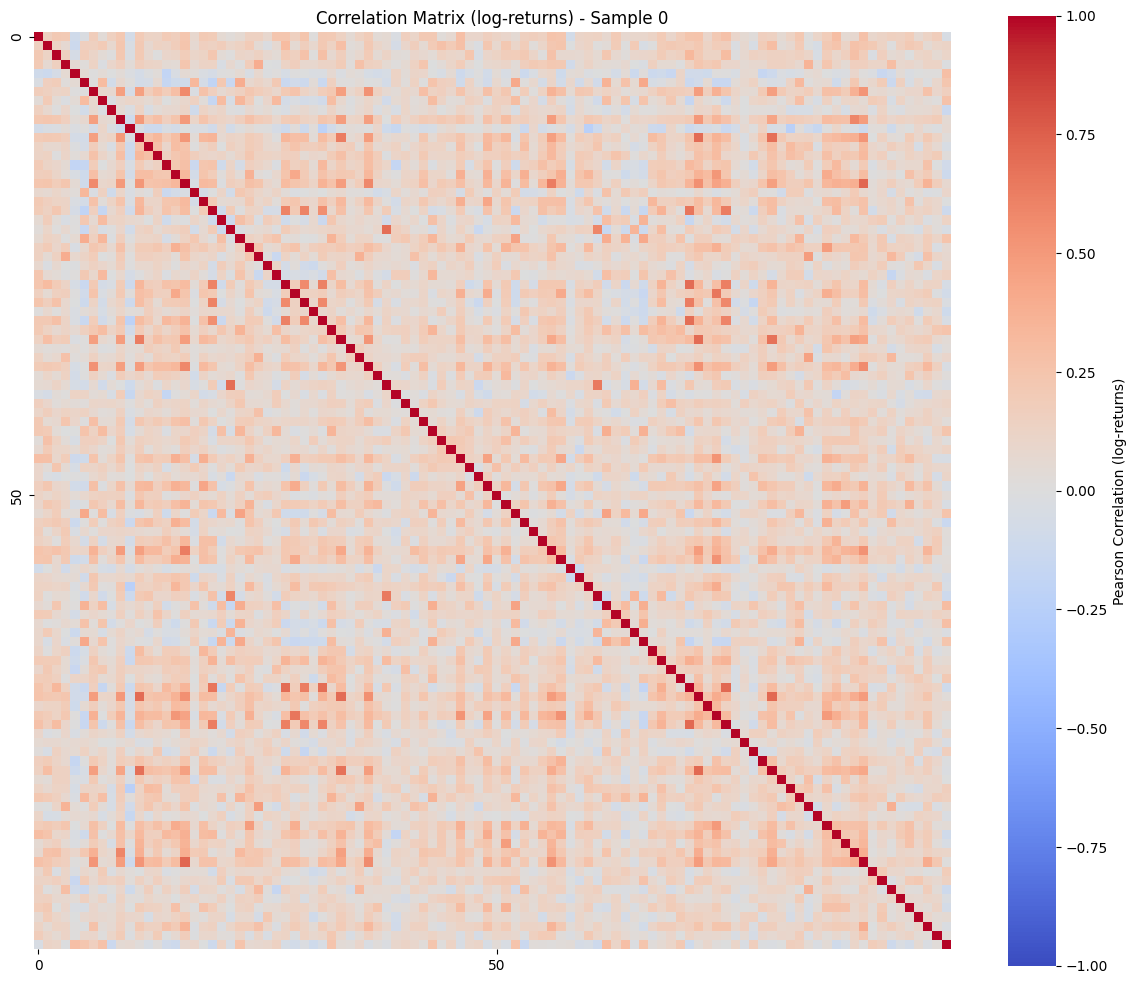

In [9]:
# Extract and convert correlation matrix to numpy
idx_sample = 0
corr_matrix = dataset[idx_sample]["corr"].numpy()
num_assets = corr_matrix.shape[0]

plt.figure(figsize=(12, 10))

# Create heatmap
sns.heatmap(
    corr_matrix, 
    annot=False, 
    cmap='coolwarm', 
    center=0, 
    vmin=-1, 
    vmax=1, 
    square=True,
    xticklabels=50, 
    yticklabels=50,
    cbar_kws={'label': 'Pearson Correlation (log-returns)'}
)

plt.title(f'Correlation Matrix (log-returns) - Sample {idx_sample}')
plt.tight_layout()
plt.show()

In [10]:
print(dataset[0]["corr"][0:10,0:10])

tensor([[     1.0000,      0.1544,      0.2169,      0.2057,     -0.0992,     -0.0277,      0.1765,      0.0338,      0.1490,      0.2217],
        [     0.1544,      1.0000,      0.1290,      0.0687,     -0.1245,      0.1584,      0.1554,      0.2018,      0.0788,      0.2345],
        [     0.2169,      0.1290,      1.0000,      0.1537,     -0.0595,      0.1825,      0.1148,      0.0463,      0.0006,      0.2257],
        [     0.2057,      0.0687,      0.1537,      1.0000,      0.0578,      0.0193,      0.1307,     -0.0216,      0.1003,      0.1582],
        [    -0.0992,     -0.1245,     -0.0595,      0.0578,      1.0000,      0.0530,      0.0035,      0.0434,     -0.0052,      0.0355],
        [    -0.0277,      0.1584,      0.1825,      0.0193,      0.0530,      1.0000,      0.0020,      0.3095,     -0.0855,      0.0724],
        [     0.1765,      0.1554,      0.1148,      0.1307,      0.0035,      0.0020,      1.0000,      0.0818,      0.0723,      0.4747],
        [     0.0338

In [11]:
# Save correlation tensor (built from log-returns CSV)
output_dir = Path(f'../data/processed/{FILE_NAME}/correlation_matrices')
output_dir.mkdir(parents=True, exist_ok=True)
OUTPUT_TENSOR_PATH = output_dir / f'{FILE_NAME}_w{WINDOW_LENGTH}_s{STRIDE}.pt'

# Extract numeric columns only (excluding timestamp)
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()

# Timestamps are already aligned with log-returns rows
if 'timestamp' in df.columns:
    timestamps = pd.to_datetime(df['timestamp']).dt.strftime('%Y-%m-%d').tolist()
else:
    timestamps = list(range(len(df)))

torch.save(
    {
        'corr_tensor': dataset.tensor,
        'window_ranges': dataset.window_ranges,
        'timestamps': timestamps,
        'window_length': WINDOW_LENGTH,
        'stride': STRIDE,
        'input_type': 'log_returns',
        'tickers': numeric_columns,
    },
    OUTPUT_TENSOR_PATH,
    )

print(f'Tensor saved to: {OUTPUT_TENSOR_PATH.resolve()}')
print('\n--- Saved Output Structure ---')
print(f"corr_tensor shape: {dataset.tensor.shape}")
print(f"  - Dimension 0 (num_windows): {dataset.tensor.shape[0]} rolling windows")
print(f"  - Dimension 1 (num_assets): {dataset.tensor.shape[1]} assets")
print(f"  - Dimension 2 (num_assets): {dataset.tensor.shape[2]} assets (symmetric matrix)")
print(f"timestamps length: {len(timestamps)}")
print(f"  - First 5 timestamps: {timestamps[:5]}")
print(f"window_length: {WINDOW_LENGTH} days per window")
print(f"stride: {STRIDE} days between consecutive windows")
print("input_type: log_returns (loaded from CSV)")
print(f"num_tickers: {len(numeric_columns)} tickers")
print(f"tickers: {numeric_columns[:5]}... (showing first 5)")

Tensor saved to: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\data\processed\data_00_20\correlation_matrices\data_00_20_w252_s5.pt

--- Saved Output Structure ---
corr_tensor shape: torch.Size([1017, 100, 100])
  - Dimension 0 (num_windows): 1017 rolling windows
  - Dimension 1 (num_assets): 100 assets
  - Dimension 2 (num_assets): 100 assets (symmetric matrix)
timestamps length: 5333
  - First 5 timestamps: ['1999-11-02', '1999-11-03', '1999-11-04', '1999-11-05', '1999-11-08']
window_length: 252 days per window
stride: 5 days between consecutive windows
input_type: log_returns (loaded from CSV)
num_tickers: 100 tickers
tickers: ['ABC', 'ADP', 'AES', 'AIV', 'AJG']... (showing first 5)


In [12]:
# Load and display the saved .pt file contents
loaded_data = torch.load(OUTPUT_TENSOR_PATH)

for key, value in loaded_data.items():
    if isinstance(value, torch.Tensor):
        print(f"{key}: torch.Tensor")
        print(f"  - Shape: {value.shape}")
        print(f"  - Dtype: {value.dtype}")
        print(f"  - Device: {value.device}")
    elif isinstance(value, list):
        print(f"{key}: list")
        print(f"  - Length: {len(value)}")
        if len(value) > 0:
            print(f"  - First 5 elements: {value[:5]}")
    elif isinstance(value, tuple):
        print(f"{key}: tuple")
        print(f"  - Length: {len(value)}")
        if len(value) > 0:
            print(f"  - First 3 elements: {value[:3]}")
    else:
        print(f"{key}: {type(value).__name__}")
        print(f"  - Value: {value}")
    print()

corr_tensor: torch.Tensor
  - Shape: torch.Size([1017, 100, 100])
  - Dtype: torch.float32
  - Device: cpu

window_ranges: list
  - Length: 1017
  - First 5 elements: [(0, 252), (5, 257), (10, 262), (15, 267), (20, 272)]

timestamps: list
  - Length: 5333
  - First 5 elements: ['1999-11-02', '1999-11-03', '1999-11-04', '1999-11-05', '1999-11-08']

window_length: int
  - Value: 252

stride: int
  - Value: 5

input_type: str
  - Value: log_returns

tickers: list
  - Length: 100
  - First 5 elements: ['ABC', 'ADP', 'AES', 'AIV', 'AJG']

